<a href="https://colab.research.google.com/github/ckCrimson/Field_Dynamic_System/blob/FD_FRAMEWORK_PACKAGE/Research_paper_systems_implementation/random_dice_system_implementation/Random_Dice_System_%E2%80%94_A_Worked_Example_in_the_Field_Dynamic_Systems_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Git hub Setup

In [79]:
!rm -rf Field_Dynamic_System  # optional: clean old copy
!git clone -b FD_FRAMEWORK_PACKAGE https://github.com/ckCrimson/Field_Dynamic_System.git

Cloning into 'Field_Dynamic_System'...
remote: Enumerating objects: 27807, done.
remote: Counting objects: 100% (194/194), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 27807 (delta 93), reused 106 (delta 41), pack-reused 27613 (from 2)
Receiving objects: 100% (27807/27807), 157.68 MiB | 18.85 MiB/s, done.
Resolving deltas: 100% (7890/7890), done.


In [80]:
import sys, pathlib, types

project_root = pathlib.Path("/content/Field_Dynamic_System")
src_root = project_root / "src"

# 1) Make sure src/ is on sys.path so Python can see the fds package
if str(src_root) not in sys.path:
    sys.path.append(str(src_root))

# 2) Create a fake top-level package called "src" that points at src_root
src_pkg = types.ModuleType("src")
src_pkg.__path__ = [str(src_root)]
sys.modules["src"] = src_pkg

# 3) Now try importing
from fds import *
print("FDS Framework imported successfully!")


FDS Framework imported successfully!


# Random Dice System

## CONSTANTS

In [81]:
PLOT_SIZE=4
GIT_UPLOAD_PATH = "Research_paper_systems_implementation/random_dice_system_implementation"

## Core

### State

#### Imports

In [82]:
import numpy as np
from numpy.typing import NDArray
from dataclasses import dataclass
from itertools import combinations
import matplotlib.pyplot as plt


from fds.core.fds_state.state import State
from fds.core.fds_state.state_space import DiscreteFiniteStatSpace
from fds.core.fds_state.reachable import Reachable
from fds.dynamics.multi_step.multi_step_reaching import MultiStepReaching

#### Random Dice State

In [83]:
class DiceState(State):
  state: NDArray[np.float64]

  def __post_init__(self):
        # 1. Make the array immutable (read-only)
        self.state.flags.writeable = False

  def __hash__(self):
        # 2. Hash the bytes of the array data
        # Note: We must explicitly tell Python how to hash this field
        return hash(self.state.tobytes())

  def __eq__(self, other):
        # 3. Define equality check
        if not isinstance(other, ImmutableVector):
            return NotImplemented
        return np.array_equal(self.state, other.state)

  def __str__(self):
    return f"{self.state}"

  def show(self):
    frequencies = self.state
    frequencies = np.array(frequencies)
    l = len(frequencies)

    # Generate labels (1 to l)
    labels = np.arange(1, l + 1)

    # Calculate Expected Value E[X]
    total_count = np.sum(frequencies)
    if total_count == 0:
        expected_value = 0
    else:
        probs = frequencies / total_count
        expected_value = np.sum(labels * probs)

    # --- Plotting Setup ---
    # Set a professional style
    plt.style.use('ggplot')

    fig, ax = plt.subplots(figsize=(PLOT_SIZE, PLOT_SIZE))

    # Create bars with aesthetic tweaks
    bars = ax.bar(labels, frequencies,
                  color='#5DA5DA',       # Nice soft blue
                  edgecolor='#4D4D4D',   # Dark gray edges
                  linewidth=1.2,
                  alpha=0.85,            # Slight transparency
                  width=0.7,
                  label='Frequency')

    # Add value annotations on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # Offset text slightly up
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color='#333333')

    # Add Expected Value Line
    ax.axvline(expected_value, color='#F15854', linestyle='--', linewidth=2.5,
               label=f'Expected Value ($\mu$): {expected_value:.2f}')

    # --- Add Transparent Text Box for the Mean at the Top ---
    # The bbox=dict(facecolor='none', edgecolor='none') creates the transparent box.
    # transform=ax.transAxes allows using relative coordinates (0-1) for placement.
    ax.text(0.5, 1.05,  # Position: Center (0.5) and slightly above the top (1.05)
            f'Mean (Expected Value): {expected_value:.2f}',
            transform=ax.transAxes,
            fontsize=13, fontweight='bold', color='#F15854',
            ha='center', va='bottom',
            bbox=dict(facecolor='none', edgecolor='none', pad=5.0))

    # --- Labels and Titles ---
    ax.set_xlabel('Label (Bin)', fontsize=12, fontweight='bold', color='#333333')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold', color='#333333')

    # We removed the main title as the new text box serves that purpose
    # ax.set_title(f'Frequency Distribution (Length={l})', fontsize=14, fontweight='bold', pad=20)

    # Set x-ticks to display integers clearly if length is manageable
    if l <= 20:
        ax.set_xticks(labels)

    # Add a legend with a shadow
    ax.legend(loc='upper right', frameon=True, shadow=True, facecolor='white', framealpha=1)

    # Add a subtle grid behind the bars (axis='y')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to accommodate the new text box at the top
    plt.tight_layout()

    # Save or Show
    plt.savefig('distribution_chart_transparent_box.png')
    #print("Chart saved as 'distribution_chart_transparent_box.png'")
    plt.show()


<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-3589468474.py:65: SyntaxWarning: invalid escape sequence '\m'
  label=f'Expected Value ($\mu$): {expected_value:.2f}')


#### Random Dice State Space

In [84]:
class DiceStateSpace(DiscreteFiniteStatSpace):
  def __init__(self,states: list[DiceState]=None, current_state: DiceState=None, dice_number: int = 6):
    self.dice_number = dice_number
    if current_state is None:
      current_state = DiceState( np.zeros(dice_number) )
    if states is None:
      states =[]
      states.append(current_state)
    super().__init__(states,current_state)

  def __str__(self):
    output = ""
    for s in self.get_all_states():
      output = output + f"{s.state} \n"
    return output


#### Random Dice Reachable

In [85]:
class DiceReachable(Reachable):
  def __init__(self, alpha: int=1, dice_number:int = 6):
    self.alpha=alpha
    super().__init__()

  def get_reachable(self, state: DiceState)-> DiceStateSpace:
    n=len(state.state)
    alpha=self.alpha
    list_of_reachable_states = []
    if self.alpha<0:
        return
    elif self.alpha==0:
      list_of_reachable_states.append(state)
      return DiceStateSpace(list_of_reachable_states,state)

    # We need to choose (n - 1) positions for dividers (bars)
    # out of (alpha + n - 1) total slots (balls + dividers).
    # The iterator is efficient and does not store all combinations in memory.
    for bars in combinations(range(alpha + n - 1), n - 1):
        # We add "sentinel" bars at indices -1 and (alpha + n - 1)
        # to make the logic consistent for the first and last boxes.
        boundaries = (-1,) + bars + (alpha + n - 1,)

        # The number of balls in the i-th box is the distance between
        # the i-th and (i+1)-th divider, minus 1.
        distribution = [boundaries[i+1] - boundaries[i] - 1 for i in range(n)]

        # Print as a numpy array as requested
        new_reachable_state = DiceState (np.array(distribution)+state.state)
        list_of_reachable_states.append(new_reachable_state)
    return DiceStateSpace(list_of_reachable_states ,list_of_reachable_states[0])


#### Rndom Dice Multi Step Reaching

In [86]:
class DiceMultiStepReaching(MultiStepReaching):
  def __init__(self,alpha:int=1):
    self.alpha=alpha
    reachable = DiceReachable(alpha)
    super().__init__(reachable)

  def get_reaching(
            self,  initial_state: DiceState,l: int,
            reference_space: DiceStateSpace=None,
            get_reaching_from_allowed: bool = False,
    ):
    multi_reachable = DiceReachable(l*self.alpha)
    return multi_reachable.get_reachable(initial_state)



### Example

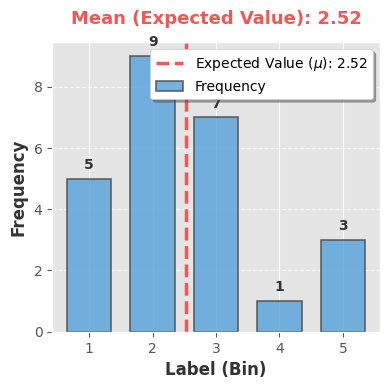

Initial State:  [5 9 7 1 3]


In [87]:
initial_state = DiceState(np.array([5,9,7,1,3]))
initial_state.show()
print("Initial State: ",initial_state)

dice_reachable = DiceReachable(2)
dice_reachabl_space =  dice_reachable.get_reachable(initial_state)


multi_dtep_dice_reachable = DiceMultiStepReaching(4)

multi_step_reachable_space =multi_dtep_dice_reachable.get_reaching(initial_state,3)


### Random Dice Field

#### Imports

In [88]:
from fds.core.fds_field.single_field_value import SingleFieldValue
from fds.core.fds_field.single_field_value_composition import *
from fds.core.fds_field.single_field_value_transform import *
from fds.core.fds_field.field_value import FieldValue
from fds.core.fds_field.fields import Field

#### Single Field Value

In [89]:
class RealSingleFieldValue(SingleFieldValue):
  value: np.float128

  def __str__(self):
    return f"value: {self.value}"
  def __repr__(self):
    return f"value: {self.value}"

  def get_unitary_field(self):
    return RealSingleFieldValue(1)

  def get_zero_field(self):
    return RealSingleFieldValue(0)

#### Single Field Value Addition

In [90]:
class RealSingleFieldValueAddition(AdditionComposition):

  def compose(self, input1: RealSingleFieldValue, input2: RealSingleFieldValue) -> RealSingleFieldValue:
    return RealSingleFieldValue( input1.value + input2.value )

#### Single Field Value Norm

In [91]:
class RealSingleFieldValueNorm(NormTransform):
  def apply(self, inputFieldValue : RealSingleFieldValue) -> SingleFieldValue:
    return inputFieldValue

#### Field Value

In [92]:
class RealFieldValue(FieldValue):
  data: SingleFieldValue

  def get_zero_field(self):
    return RealFieldValue(RealSingleFieldValue(0))

  def get_unitary_field(self):
    return RealFieldValue(RealSingleFieldValue(1))

  @classmethod
  def define_from_value(self,value: np.float128):
    return RealFieldValue(RealSingleFieldValue(value))

  def __str__(self):
    return f"value: {self.data.value}"


RealFieldValue.configure(RealSingleFieldValueNorm(),RealSingleFieldValueAddition())

#### Real Field

In [103]:
class RealField(Field):
  def __def__(state_space: DiceStateSpace, unit_field =  RealFieldValue.define_from_value(1)):
    super().__init__(state_space,unit_field)

  def __str__(self):
    repr = ""
    ids = self.state_space.ids_view()
    for s in ids:
      state = self.state_space.get_state_by_id(int(s))
      repr = repr + str(state.state)
      repr = repr+" : "
      repr = repr+ str(self.get_field(state).value)
      repr = repr+"\n"
    return repr

  def __repr__(self):
    repr = ""
    ids = self.state_space.ids_view()
    for s in ids:
      state = self.state_space.get_state_by_id(int(s))
      repr = repr + str(state.state)
      repr = repr+" : "
      repr = repr+ str(self.get_field(state).value )
      repr = repr+"\n"
    return repr



#### Example

In [104]:
single_field = RealSingleFieldValue(1)
print("Single Field: ",single_field)
field_value = RealFieldValue(single_field)
field_value_from_float = RealFieldValue.define_from_value(19)

print("Field Value: ", field_value)
print("Field Value from Value: ",field_value_from_float)

added_field=RealSingleFieldValueAddition().compose(single_field,single_field)
print("Adding: ",added_field)

norm_field = RealSingleFieldValueNorm().apply(single_field)
print("Norm: ",norm_field)


dice_state_space_field = DiceReachable(2,8).get_reachable(initial_state)
real_field =   RealField(dice_state_space_field,single_field)

print(real_field)

Single Field:  value: 1
Field Value:  value: 1
Field Value from Value:  value: 19
Adding:  value: 2
Norm:  value: 1
[5 9 7 1 5] : 1
[5 9 7 2 4] : 1
[5 9 7 3 3] : 1
[5 9 8 1 4] : 1
[5 9 8 2 3] : 1
[5 9 9 1 3] : 1
[ 5 10  7  1  4] : 1
[ 5 10  7  2  3] : 1
[ 5 10  8  1  3] : 1
[ 5 11  7  1  3] : 1
[6 9 7 1 4] : 1
[6 9 7 2 3] : 1
[6 9 8 1 3] : 1
[ 6 10  7  1  3] : 1
[7 9 7 1 3] : 1

